# Load And understand Data


In [33]:
# LOAD AND UNDERSTAND DATA

import pandas as pd
import numpy as np

df = pd.read_csv("./StudentSuccess.csv")

print("Sample Rows")
print(df.head())

print("\nDataset Shape")
print(f"Rows : {df.shape[0]} ,Columns : {df.shape[1]}")

print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe(include="all"))

print("\nMissing Values")
print(df.isnull().sum())

Sample Rows
   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      Yes           5     No
1           5          80         60       No           6    Yes
2           8          90         75      Yes           8    Yes
3           3          70         50      Yes           5     No
4           7          85         70       No           7    Yes

Dataset Shape
Rows : 20 ,Columns : 6

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None

Summary Statistics
        StudyHours  Attendance  PastScore Interne

# PREPROCCESING

    Cateogorical value should convert in Numerical Value
    LabelEncoder Or getDummies can be used

    labelEncoder for (yes / no ) type values
    and
    getDummies for (delhi/Mumbai/chennai/....) types value

In [34]:


from sklearn.preprocessing import LabelEncoder

print("Missing Value in Each Column")
print(df.isna().sum())

le=LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet']) #yes=1,No=0
df['Passed'] = le.fit_transform(df['Passed']) 

print('\nAfter Encoding\n')
print(df.head())

print('\nData types After Cleaning')
print(df.dtypes)


Missing Value in Each Column
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64

After Encoding

   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           2          60         40         1           5       0
1           5          80         60         0           6       1
2           8          90         75         1           8       1
3           3          70         50         1           5       0
4           7          85         70         0           7       1

Data types After Cleaning
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours    int64
Passed        int64
dtype: object


# FEATURE SCALING
    StandardScaler Or MinMaxScaler(0-1)

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

features = ['StudyHours','Attendance','PastScore','SleepHours']
scaler=StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

x= df_scaled[features] #features
y = df_scaled['Passed'] #target

# SPLIT DATA

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# TRAIN DATA

In [37]:

model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# MAKE PREDICTION

In [38]:
y_pred = model.predict(x_test)

# EVALUATE MODEL

In [39]:
print("\nClassification Report")
print(classification_report(y_test,y_pred))

conf_matrix = confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix")
print(conf_matrix)



Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix
[[1 0]
 [0 3]]


# VISUALIZE RESULT

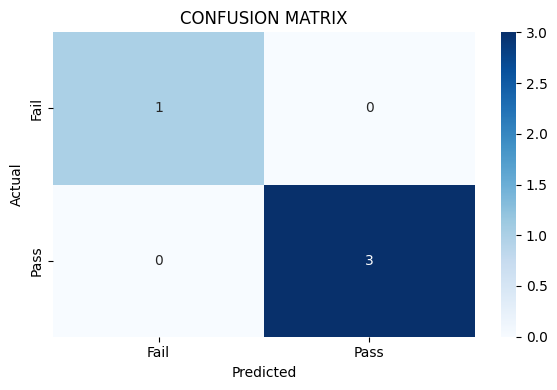

In [40]:
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('CONFUSION MATRIX')
plt.tight_layout()
plt.show()


# USER INTERACTION

In [41]:
print("===============Predict Your result===============")
try:
    study_hour = float(input("Enter Study Hour : "))
    attendance = float(input("Enter Attendance : "))
    past_score = float(input("Enter Past Score : "))
    sleep_hour = float(input("Enter Sleep Hour : "))

    user_input_df = pd.DataFrame([{
        'StudyHours':study_hour,
        'Attendance':attendance,
        'PastScore':past_score,
        'SleepHours':sleep_hour
    }])

    user_input_scaled = scaler.transform(user_input_df)
    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction ==1 else "Fail"
    print(f"Prediction Based on input : {result}")

except Exception as e:
    print("An Error Occured ",e)


===============Predict Your result===============
Prediction Based on input : Pass


C:\Users\princ\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# FURTHER IMPROVEMENT AND WRAP UP